# Lesson 4. Systems of Differential Equations I
## Companion Notebook — Examples & Visualizations

**Topics covered:**
1. Converting Higher-Order ODEs to Systems
2. Equilibrium Points
3. Stability (Lyapunov and Asymptotic)
4. Classification of Equilibria by Eigenvalues
5. Phase Portrait Examples (Node, Saddle, Focus)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---
## 1. Converting Higher-Order ODEs to Systems

Any $n$-th order ODE can be rewritten as a system of $n$ first-order ODEs using substitution.

**Standard form:**
$$\begin{cases} x_1' = f_1(t, x_1, \ldots, x_n) \\ \vdots \\ x_n' = f_n(t, x_1, \ldots, x_n) \end{cases}$$

### Example 1: Damped Harmonic Oscillator

$$m x'' + b x' + k x = 0$$

Setting $x_1 = x$, $x_2 = x'$:
$$\begin{cases} x_1' = x_2 \\ x_2' = -\frac{b}{m} x_2 - \frac{k}{m} x_1 \end{cases}$$

This is a **linear** system (right-hand sides are linear in $x_1, x_2$).

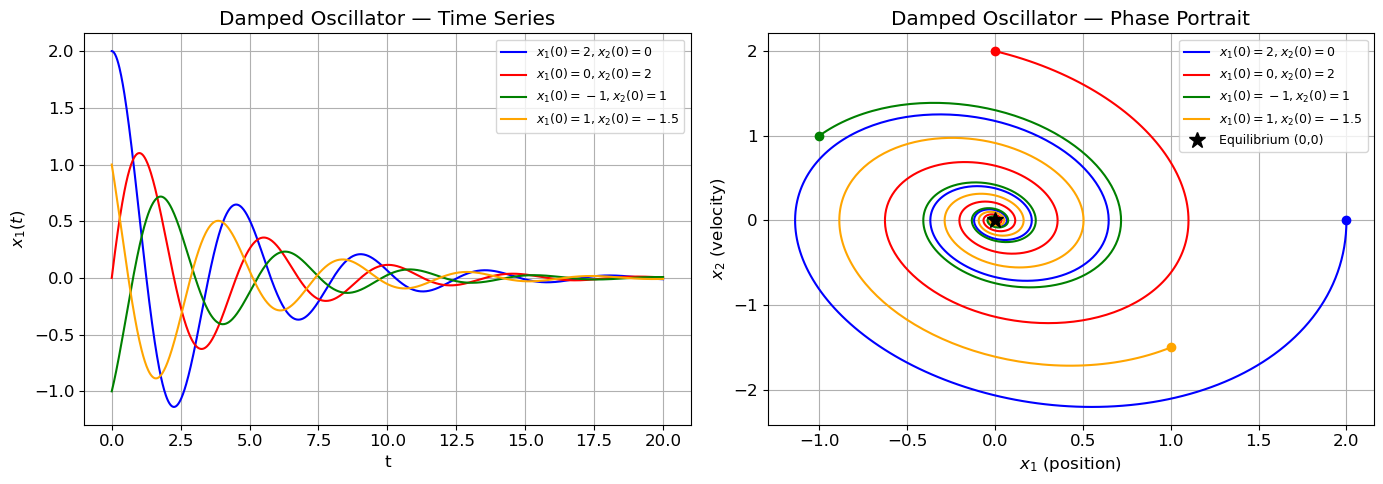

Parameters: m=1.0, b=0.5, k=2.0
System matrix A = [[ 0, 1], [-2.0, -0.5]]
All trajectories spiral into the origin → asymptotically stable equilibrium.


In [2]:
# Damped harmonic oscillator: m=1, b=0.5, k=2
m, b, k = 1.0, 0.5, 2.0

def damped_oscillator(t, X):
    x1, x2 = X
    return [x2, -(b/m)*x2 - (k/m)*x1]

t_span = [0, 20]
t_eval = np.linspace(*t_span, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Solve for several initial conditions
ics = [(2, 0), (0, 2), (-1, 1), (1, -1.5)]
colors = ['blue', 'red', 'green', 'orange']

for (x10, x20), color in zip(ics, colors):
    sol = solve_ivp(damped_oscillator, t_span, [x10, x20], t_eval=t_eval, rtol=1e-10)
    label = f'$x_1(0)={x10}, x_2(0)={x20}$'
    # Time series
    axes[0].plot(sol.t, sol.y[0], color=color, linewidth=1.5, label=label)
    # Phase portrait
    axes[1].plot(sol.y[0], sol.y[1], color=color, linewidth=1.5, label=label)
    axes[1].plot(x10, x20, 'o', color=color, markersize=6)

axes[0].set_xlabel('t'); axes[0].set_ylabel('$x_1(t)$')
axes[0].set_title('Damped Oscillator — Time Series')
axes[0].legend(fontsize=9); axes[0].grid(True)

axes[1].set_xlabel('$x_1$ (position)'); axes[1].set_ylabel('$x_2$ (velocity)')
axes[1].set_title('Damped Oscillator — Phase Portrait')
axes[1].plot(0, 0, 'k*', markersize=12, label='Equilibrium (0,0)')
axes[1].legend(fontsize=9); axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Parameters: m={m}, b={b}, k={k}")
print(f"System matrix A = [[ 0, 1], [-{k/m}, -{b/m}]]")
print(f"All trajectories spiral into the origin → asymptotically stable equilibrium.")

### Example 2: Simple Pendulum (Nonlinear)

$$x'' + \frac{g}{L}\sin(x) = 0$$

Setting $x_1 = x$, $x_2 = x'$:
$$\begin{cases} x_1' = x_2 \\ x_2' = -\frac{g}{L} \sin(x_1) \end{cases}$$

This is a **nonlinear** system due to the $\sin(x_1)$ term.

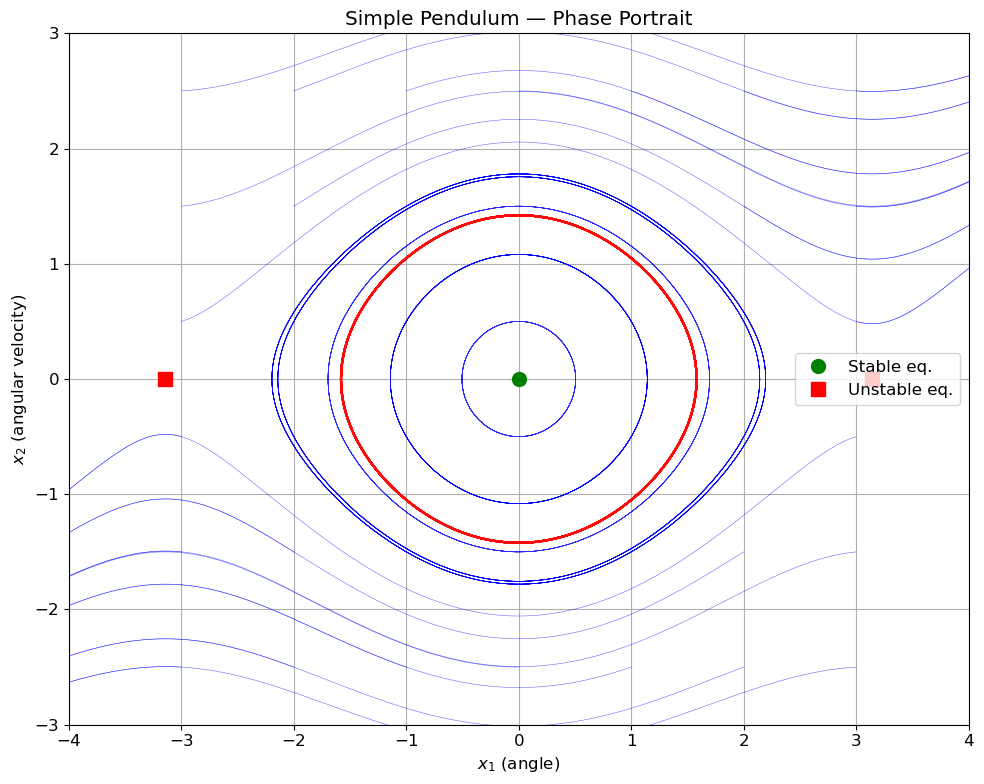

Equilibria at (πn, 0):
  n even (0, ±2π, ...): stable (center) — pendulum hangs down
  n odd  (±π, ±3π, ...): unstable (saddle) — pendulum points up


In [3]:
# Simple pendulum (no damping): g/L = 1
gL = 1.0

def pendulum(t, X):
    x1, x2 = X
    return [x2, -gL * np.sin(x1)]

fig, ax = plt.subplots(figsize=(10, 8))

# Multiple initial conditions for a rich phase portrait
for x10 in np.linspace(-3, 3, 7):
    for x20 in np.linspace(-2.5, 2.5, 6):
        sol = solve_ivp(pendulum, [0, 30], [x10, x20],
                        t_eval=np.linspace(0, 30, 2000), rtol=1e-10)
        ax.plot(sol.y[0], sol.y[1], 'b-', linewidth=0.4, alpha=0.6)

# Also plot separatrices (trajectories near energy = 2gL)
for sign in [1, -1]:
    for eps in [0.01]:
        x20_sep = sign * np.sqrt(2*gL*(1 + eps))  # energy just above critical
        sol = solve_ivp(pendulum, [0, 50], [0, x20_sep],
                        t_eval=np.linspace(0, 50, 5000), rtol=1e-12)
        ax.plot(sol.y[0], sol.y[1], 'r-', linewidth=1.5, alpha=0.8)

# Mark equilibrium points
for n in range(-1, 2):
    xeq = n * np.pi
    if n % 2 == 0:
        ax.plot(xeq, 0, 'go', markersize=10, label='Stable eq.' if n == 0 else '')
    else:
        ax.plot(xeq, 0, 'rs', markersize=10, label='Unstable eq.' if n == 1 else '')

ax.set_xlabel('$x_1$ (angle)'); ax.set_ylabel('$x_2$ (angular velocity)')
ax.set_title('Simple Pendulum — Phase Portrait')
ax.set_xlim(-4, 4); ax.set_ylim(-3, 3)
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

print("Equilibria at (πn, 0):")
print("  n even (0, ±2π, ...): stable (center) — pendulum hangs down")
print("  n odd  (±π, ±3π, ...): unstable (saddle) — pendulum points up")

---
## 2. Equilibrium Points

**Equilibrium points** (critical/stationary points) satisfy $f_i(\mathbf{x}^*) = 0$ for all $i$.

At equilibrium, the system does not change — once reached, it stays there indefinitely.

=== Damped Harmonic Oscillator ===
System: x1' = x2,  x2' = -(k/m)*x1 - (b/m)*x2


Equilibrium: {x1: 0, x2: 0}

=== Simple Pendulum ===
System: x1' = x2,  x2' = -(g/L)*sin(x1)


Equilibrium solutions (sympy): [(0, 0), (pi, 0)]
Full set: (x1, x2) = (nπ, 0) for all integers n



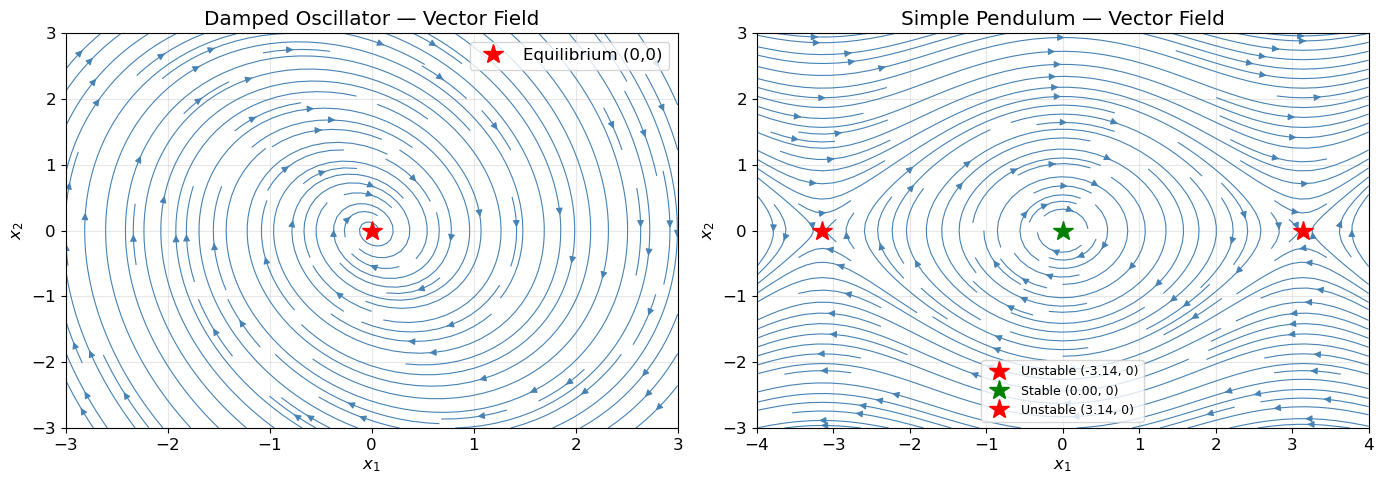

In [4]:
x1_s, x2_s = sp.symbols('x1 x2')

# Damped oscillator equilibria
print("=== Damped Harmonic Oscillator ===")
print("System: x1' = x2,  x2' = -(k/m)*x1 - (b/m)*x2")
k_s, b_s, m_s = sp.symbols('k b m', positive=True)
eq1 = sp.solve([x2_s, -(k_s/m_s)*x1_s - (b_s/m_s)*x2_s], [x1_s, x2_s])
print(f"Equilibrium: {eq1}")
print()

# Pendulum equilibria
print("=== Simple Pendulum ===")
print("System: x1' = x2,  x2' = -(g/L)*sin(x1)")
g_s, L_s = sp.symbols('g L', positive=True)
eq2 = sp.solve([x2_s, -g_s/L_s * sp.sin(x1_s)], [x1_s, x2_s])
print(f"Equilibrium solutions (sympy): {eq2}")
print("Full set: (x1, x2) = (nπ, 0) for all integers n")
print()

# Visualize equilibria on a vector field
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Damped oscillator vector field
X1, X2 = np.meshgrid(np.linspace(-3, 3, 20), np.linspace(-3, 3, 20))
U1 = X2
V1 = -0.5*X2 - 2*X1  # b/m=0.5, k/m=2
axes[0].streamplot(X1, X2, U1, V1, density=1.5, color='steelblue', linewidth=0.8)
axes[0].plot(0, 0, 'r*', markersize=15, label='Equilibrium (0,0)')
axes[0].set_xlabel('$x_1$'); axes[0].set_ylabel('$x_2$')
axes[0].set_title('Damped Oscillator — Vector Field')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Pendulum vector field
X1p, X2p = np.meshgrid(np.linspace(-4, 4, 20), np.linspace(-3, 3, 20))
U2 = X2p
V2 = -np.sin(X1p)
axes[1].streamplot(X1p, X2p, U2, V2, density=1.5, color='steelblue', linewidth=0.8)
for n in range(-1, 2):
    xeq = n * np.pi
    marker = 'g*' if n % 2 == 0 else 'r*'
    lbl = 'Stable' if n % 2 == 0 else 'Unstable'
    axes[1].plot(xeq, 0, marker, markersize=15,
                 label=f'{lbl} ({xeq:.2f}, 0)' if abs(n) <= 1 else '')
axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')
axes[1].set_title('Simple Pendulum — Vector Field')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. Stability: Lyapunov vs Asymptotic

- **Lyapunov stable**: trajectories starting near the equilibrium stay near it for all $t \geq 0$.
- **Asymptotically stable**: Lyapunov stable AND trajectories converge to the equilibrium as $t \to \infty$.

We compare the damped ($b > 0$, asymptotically stable) and undamped ($b = 0$, Lyapunov stable but not asymptotic) harmonic oscillator.

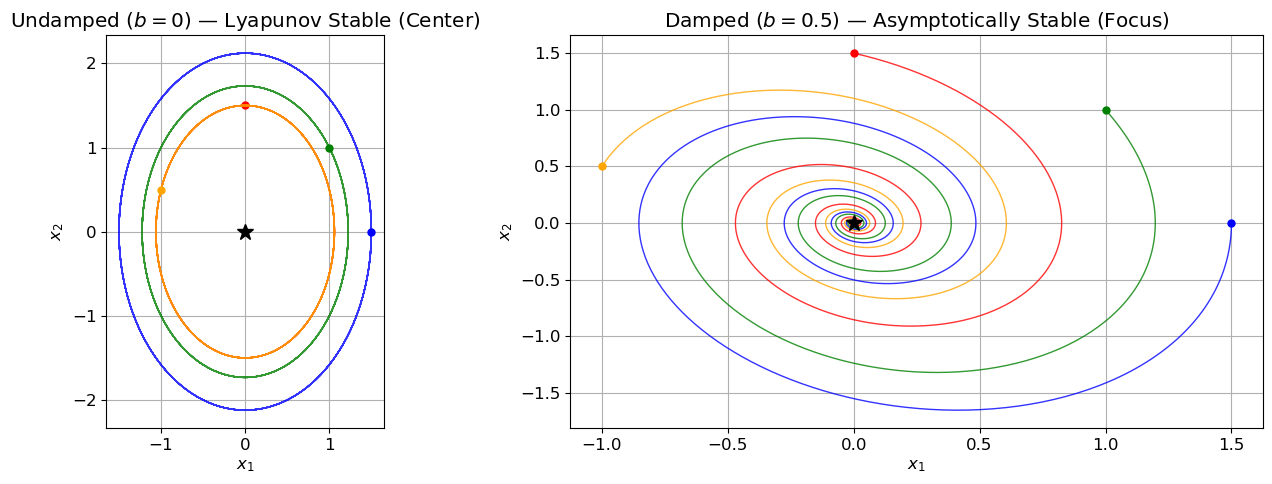

Left: Closed orbits — trajectories stay near the origin but never converge.
Right: Spiraling inward — trajectories converge to the origin as t → ∞.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

t_span = [0, 30]
t_eval = np.linspace(*t_span, 2000)

# Undamped oscillator (b=0): Lyapunov stable (center)
def undamped(t, X):
    return [X[1], -2.0*X[0]]  # k/m=2, b=0

# Damped oscillator (b=0.5): asymptotically stable
def damped(t, X):
    return [X[1], -0.5*X[1] - 2.0*X[0]]  # k/m=2, b/m=0.5

ics = [(1.5, 0), (0, 1.5), (1, 1), (-1, 0.5)]
colors = ['blue', 'red', 'green', 'orange']

for (x10, x20), color in zip(ics, colors):
    # Undamped
    sol_u = solve_ivp(undamped, t_span, [x10, x20], t_eval=t_eval, rtol=1e-10)
    axes[0].plot(sol_u.y[0], sol_u.y[1], color=color, linewidth=1, alpha=0.8)
    axes[0].plot(x10, x20, 'o', color=color, markersize=5)
    # Damped
    sol_d = solve_ivp(damped, t_span, [x10, x20], t_eval=t_eval, rtol=1e-10)
    axes[1].plot(sol_d.y[0], sol_d.y[1], color=color, linewidth=1, alpha=0.8)
    axes[1].plot(x10, x20, 'o', color=color, markersize=5)

axes[0].plot(0, 0, 'k*', markersize=12)
axes[0].set_xlabel('$x_1$'); axes[0].set_ylabel('$x_2$')
axes[0].set_title('Undamped ($b=0$) — Lyapunov Stable (Center)')
axes[0].set_aspect('equal'); axes[0].grid(True)

axes[1].plot(0, 0, 'k*', markersize=12)
axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')
axes[1].set_title('Damped ($b=0.5$) — Asymptotically Stable (Focus)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Left: Closed orbits — trajectories stay near the origin but never converge.")
print("Right: Spiraling inward — trajectories converge to the origin as t → ∞.")

---
## 4. Classification of Equilibria by Eigenvalues

For the 2D linear system $\mathbf{x}' = A\mathbf{x}$ with $\det A \neq 0$:

| Type | Eigenvalues $\lambda_1, \lambda_2$ | Stability |
|------|--------|----------|
| **Node** | Real, same sign | Stable if $\lambda < 0$, unstable if $\lambda > 0$ |
| **Saddle** | Real, opposite sign | Always unstable |
| **Focus** | Complex conjugate, $\text{Re} \neq 0$ | Stable if $\text{Re} < 0$, unstable if $\text{Re} > 0$ |
| **Center** | Purely imaginary | Lyapunov stable (not asymptotic) |

<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Szekeres Béla\AppData\Local\Temp\ipykernel_30544\268031514.py:30: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title(f'{name}\n$\lambda = {eigenvalues[0]:.2f}, {eigenvalues[1]:.2f}$')


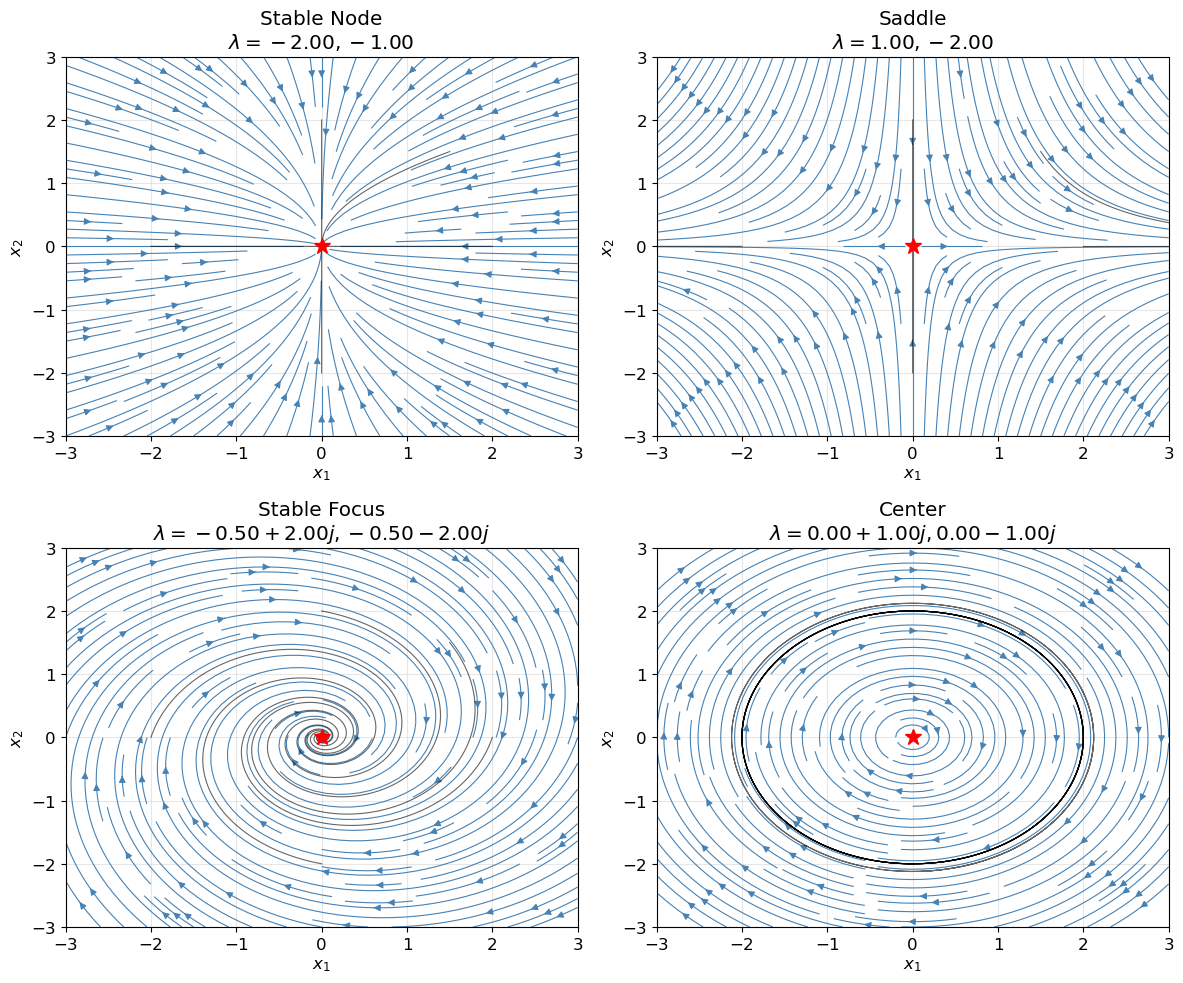

Eigenvalue summary:
  Stable Node    : λ =    -2.0000,    -1.0000
  Saddle         : λ =     1.0000,    -2.0000
  Stable Focus   : λ = -0.5000+2.0000j, -0.5000-2.0000j
  Center         : λ = 0.0000+1.0000j, 0.0000-1.0000j


In [6]:
# Demonstrate all 4 equilibrium types
systems = {
    'Stable Node': np.array([[-2, 0], [0, -1]]),
    'Saddle': np.array([[1, 0], [0, -2]]),
    'Stable Focus': np.array([[-0.5, 2], [-2, -0.5]]),
    'Center': np.array([[0, 1], [-1, 0]]),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, A) in enumerate(systems.items()):
    ax = axes[idx]
    eigenvalues = np.linalg.eigvals(A)

    # Vector field
    X1, X2 = np.meshgrid(np.linspace(-3, 3, 20), np.linspace(-3, 3, 20))
    U = A[0, 0]*X1 + A[0, 1]*X2
    V = A[1, 0]*X1 + A[1, 1]*X2
    ax.streamplot(X1, X2, U, V, density=1.5, color='steelblue', linewidth=0.8)

    # Trajectories
    for x10, x20 in [(2, 0), (0, 2), (-2, 0), (0, -2), (1.5, 1.5)]:
        def sys(t, X, A=A): return A @ X
        sol = solve_ivp(sys, [0, 15], [x10, x20],
                        t_eval=np.linspace(0, 15, 1500), rtol=1e-10)
        ax.plot(sol.y[0], sol.y[1], 'k-', linewidth=0.8, alpha=0.6)

    ax.plot(0, 0, 'r*', markersize=12)
    ax.set_title(f'{name}\n$\lambda = {eigenvalues[0]:.2f}, {eigenvalues[1]:.2f}$')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Eigenvalue summary:")
for name, A in systems.items():
    eigs = np.linalg.eigvals(A)
    print(f"  {name:15s}: λ = {eigs[0]:10.4f}, {eigs[1]:10.4f}")

---
## 5. Phase Portrait Examples

We now work through the three detailed examples from the lecture notes, following the 6-step procedure:
1. Find eigenvalues
2. Classify the equilibrium and determine stability
3. Find isoclines ($x_1' = 0$ and $x_2' = 0$)
4. Compute eigenvectors (for nodes/saddles) and draw asymptotes
5. Sketch the phase portrait
6. Determine direction of motion

### Example 1: Stable Node

$$\begin{cases} x_1' = -x_1 \\ x_2' = 2x_1 - 2x_2 \end{cases}, \quad A = \begin{bmatrix} -1 & 0 \\ 2 & -2 \end{bmatrix}$$

System matrix A =
⎡-1  0 ⎤
⎢      ⎥
⎣2   -2⎦

det(A) = 2 ≠ 0 → unique equilibrium at (0, 0)

Eigenvalues and eigenvectors:
  λ = -2, multiplicity = 1, eigenvector = Matrix([[0, 1]])
  λ = -1, multiplicity = 1, eigenvector = Matrix([[1/2, 1]])

Both eigenvalues are real and negative → STABLE NODE
Trajectories approach origin tangent to V1 = (1, 2) (|λ1|=1 < |λ2|=2)


<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Szekeres Béla\AppData\Local\Temp\ipykernel_30544\443884979.py:43: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title('Example 1: Stable Node — $\lambda_1=-1, \lambda_2=-2$')


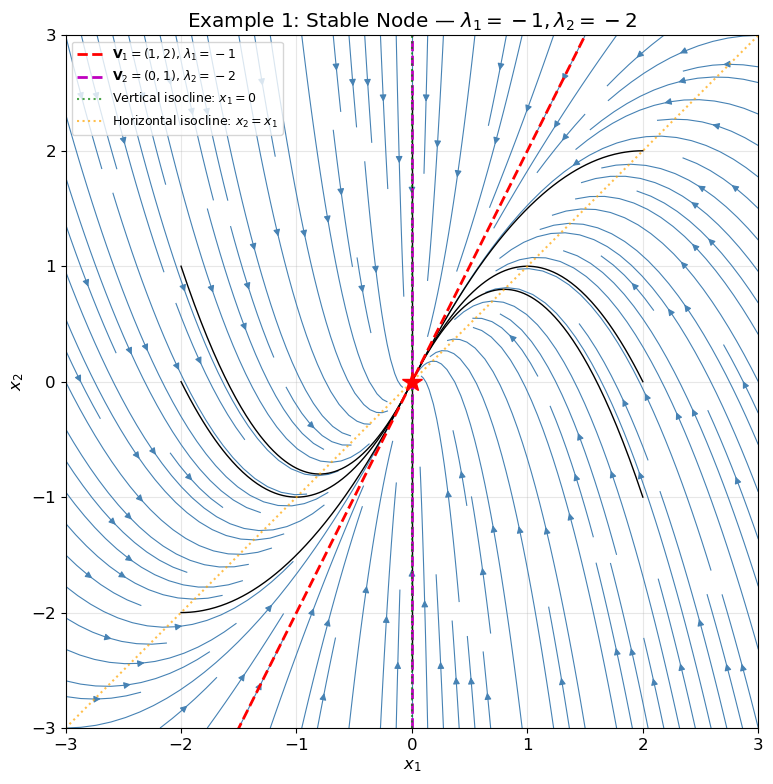

In [7]:
A1 = sp.Matrix([[-1, 0], [2, -2]])
print("System matrix A =")
sp.pprint(A1)
print(f"\ndet(A) = {A1.det()} ≠ 0 → unique equilibrium at (0, 0)")

# Eigenvalues and eigenvectors
eig = A1.eigenvects()
print("\nEigenvalues and eigenvectors:")
for eigenval, mult, vecs in eig:
    print(f"  λ = {eigenval}, multiplicity = {mult}, eigenvector = {vecs[0].T}")

print("\nBoth eigenvalues are real and negative → STABLE NODE")
print("Trajectories approach origin tangent to V1 = (1, 2) (|λ1|=1 < |λ2|=2)")

# Numerical phase portrait
A1_num = np.array([[-1, 0], [2, -2]], dtype=float)

fig, ax = plt.subplots(figsize=(8, 8))

# Stream plot
X1, X2 = np.meshgrid(np.linspace(-3, 3, 20), np.linspace(-3, 3, 20))
U = A1_num[0, 0]*X1 + A1_num[0, 1]*X2
V = A1_num[1, 0]*X1 + A1_num[1, 1]*X2
ax.streamplot(X1, X2, U, V, density=1.5, color='steelblue', linewidth=0.8)

# Trajectories
for x10, x20 in [(2, 0), (-2, 0), (0, 2.5), (0, -2.5), (2, 2), (-2, -2), (2, -1), (-2, 1)]:
    sol = solve_ivp(lambda t, X: A1_num @ X, [0, 10], [x10, x20],
                    t_eval=np.linspace(0, 10, 1000), rtol=1e-10)
    ax.plot(sol.y[0], sol.y[1], 'k-', linewidth=1)

# Eigenvector directions
t_line = np.linspace(-3, 3, 100)
ax.plot(t_line, 2*t_line, 'r--', linewidth=2, label=r'$\mathbf{V}_1 = (1,2)$, $\lambda_1=-1$')
ax.plot(np.zeros_like(t_line), t_line, 'm--', linewidth=2, label=r'$\mathbf{V}_2 = (0,1)$, $\lambda_2=-2$')

# Isoclines
ax.axvline(x=0, color='green', linestyle=':', linewidth=1.5, alpha=0.7, label=r"Vertical isocline: $x_1=0$")
ax.plot(t_line, t_line, 'orange', linestyle=':', linewidth=1.5, alpha=0.7, label=r"Horizontal isocline: $x_2=x_1$")

ax.plot(0, 0, 'r*', markersize=15)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Example 1: Stable Node — $\lambda_1=-1, \lambda_2=-2$')
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.legend(loc='upper left', fontsize=9); ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Example 2: Saddle

$$\begin{cases} x_1' = x_1 + 3x_2 \\ x_2' = 2x_1 \end{cases}, \quad A = \begin{bmatrix} 1 & 3 \\ 2 & 0 \end{bmatrix}$$

<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Szekeres Béla\AppData\Local\Temp\ipykernel_30544\1487140192.py:47: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title('Example 2: Saddle — $\lambda_1=3, \lambda_2=-2$')


System matrix A =
⎡1  3⎤
⎢    ⎥
⎣2  0⎦

det(A) = -6 ≠ 0 → unique equilibrium at (0, 0)

Eigenvalues and eigenvectors:
  λ = -2, eigenvector = Matrix([[-1, 1]])
  λ = 3, eigenvector = Matrix([[3/2, 1]])

Real eigenvalues with opposite signs → SADDLE (unstable)

Separatrix slopes: k = [-1, 2/3] (from 3k² + k - 2 = 0)


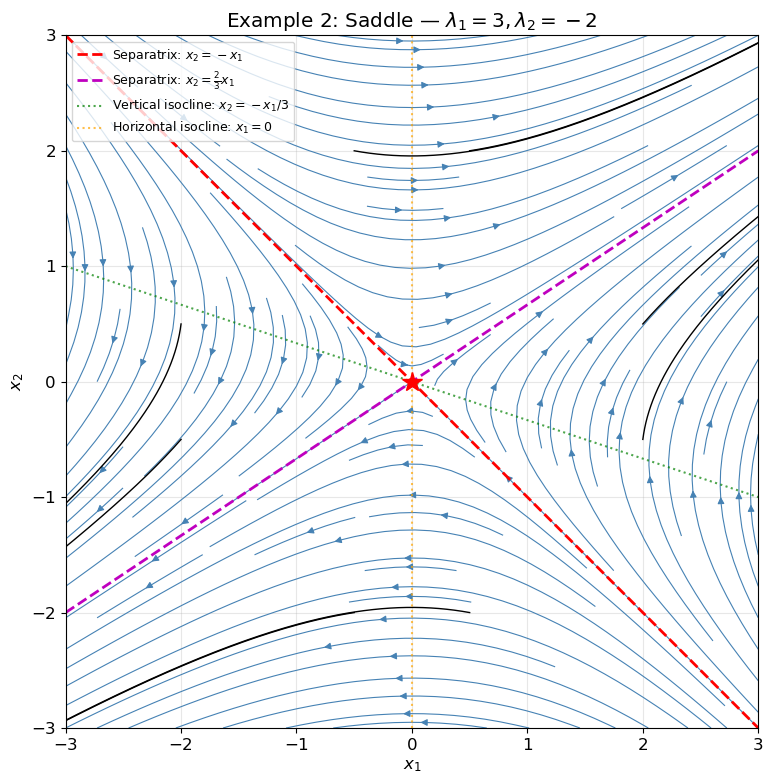

In [8]:
A2 = sp.Matrix([[1, 3], [2, 0]])
print("System matrix A =")
sp.pprint(A2)
print(f"\ndet(A) = {A2.det()} ≠ 0 → unique equilibrium at (0, 0)")

eig2 = A2.eigenvects()
print("\nEigenvalues and eigenvectors:")
for eigenval, mult, vecs in eig2:
    print(f"  λ = {eigenval}, eigenvector = {vecs[0].T}")

print("\nReal eigenvalues with opposite signs → SADDLE (unstable)")

# Separatrices: x2 = k*x1 where 3k^2 + k - 2 = 0 => k = -1, 2/3
k_sym = sp.Symbol('k')
sep_eq = 3*k_sym**2 + k_sym - 2
k_vals = sp.solve(sep_eq, k_sym)
print(f"\nSeparatrix slopes: k = {k_vals} (from 3k² + k - 2 = 0)")

# Phase portrait
A2_num = np.array([[1, 3], [2, 0]], dtype=float)

fig, ax = plt.subplots(figsize=(8, 8))

X1, X2 = np.meshgrid(np.linspace(-3, 3, 20), np.linspace(-3, 3, 20))
U = A2_num[0, 0]*X1 + A2_num[0, 1]*X2
V = A2_num[1, 0]*X1 + A2_num[1, 1]*X2
ax.streamplot(X1, X2, U, V, density=1.5, color='steelblue', linewidth=0.8)

# Trajectories
for x10, x20 in [(2, 0.5), (-2, -0.5), (0.5, 2), (-0.5, -2),
                  (2, -0.5), (-2, 0.5), (0.5, -2), (-0.5, 2)]:
    sol = solve_ivp(lambda t, X: A2_num @ X, [0, 3], [x10, x20],
                    t_eval=np.linspace(0, 3, 1000), rtol=1e-10)
    ax.plot(sol.y[0], sol.y[1], 'k-', linewidth=1)

# Separatrices
t_line = np.linspace(-3, 3, 100)
ax.plot(t_line, -t_line, 'r--', linewidth=2, label=r'Separatrix: $x_2 = -x_1$')
ax.plot(t_line, (2/3)*t_line, 'm--', linewidth=2, label=r'Separatrix: $x_2 = \frac{2}{3}x_1$')

# Isoclines
ax.plot(t_line, -t_line/3, 'g:', linewidth=1.5, alpha=0.7, label=r'Vertical isocline: $x_2=-x_1/3$')
ax.axvline(x=0, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label=r'Horizontal isocline: $x_1=0$')

ax.plot(0, 0, 'r*', markersize=15)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Example 2: Saddle — $\lambda_1=3, \lambda_2=-2$')
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.legend(loc='upper left', fontsize=9); ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Example 3: Unstable Focus

$$\begin{cases} x_1' = 3x_1 - 4x_2 \\ x_2' = 2x_1 - x_2 \end{cases}, \quad A = \begin{bmatrix} 3 & -4 \\ 2 & -1 \end{bmatrix}$$

<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Szekeres Béla\AppData\Local\Temp\ipykernel_30544\4187732988.py:37: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title('Example 3: Unstable Focus — $\lambda = 1 \pm 2i$')


System matrix A =
⎡3  -4⎤
⎢     ⎥
⎣2  -1⎦

det(A) = 5 ≠ 0 → unique equilibrium at (0, 0)

Eigenvalues:
  λ = 1 - 2*I
  λ = 1 + 2*I

Complex conjugate eigenvalues with Re(λ) = 1 > 0 → UNSTABLE FOCUS
Spirals twist counterclockwise (dx2/dt at (1,0) = 2 > 0)


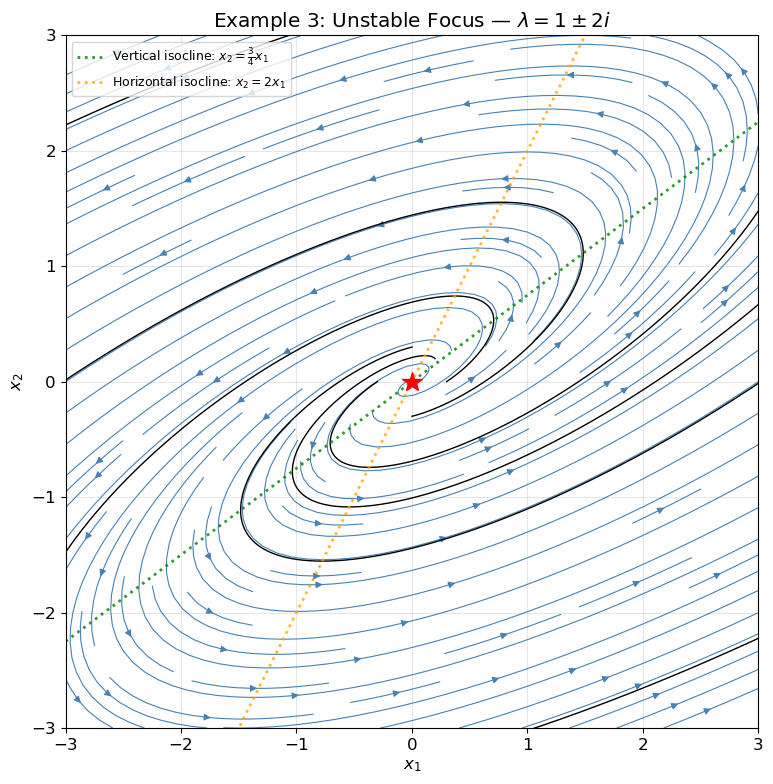

In [9]:
A3 = sp.Matrix([[3, -4], [2, -1]])
print("System matrix A =")
sp.pprint(A3)
print(f"\ndet(A) = {A3.det()} ≠ 0 → unique equilibrium at (0, 0)")

eig3 = A3.eigenvects()
print("\nEigenvalues:")
for eigenval, mult, vecs in eig3:
    print(f"  λ = {eigenval}")

print("\nComplex conjugate eigenvalues with Re(λ) = 1 > 0 → UNSTABLE FOCUS")
print("Spirals twist counterclockwise (dx2/dt at (1,0) = 2 > 0)")

# Phase portrait
A3_num = np.array([[3, -4], [2, -1]], dtype=float)

fig, ax = plt.subplots(figsize=(8, 8))

X1, X2 = np.meshgrid(np.linspace(-3, 3, 20), np.linspace(-3, 3, 20))
U = A3_num[0, 0]*X1 + A3_num[0, 1]*X2
V = A3_num[1, 0]*X1 + A3_num[1, 1]*X2
ax.streamplot(X1, X2, U, V, density=1.5, color='steelblue', linewidth=0.8)

# Trajectories (solve backward in time to show spirals going outward)
for x10, x20 in [(0.3, 0), (0, 0.3), (-0.3, 0), (0, -0.3), (0.2, 0.2)]:
    sol = solve_ivp(lambda t, X: A3_num @ X, [0, 4], [x10, x20],
                    t_eval=np.linspace(0, 4, 2000), rtol=1e-10)
    ax.plot(sol.y[0], sol.y[1], 'k-', linewidth=1)

# Isoclines
t_line = np.linspace(-3, 3, 100)
ax.plot(t_line, (3/4)*t_line, 'g:', linewidth=2, alpha=0.8, label=r'Vertical isocline: $x_2=\frac{3}{4}x_1$')
ax.plot(t_line, 2*t_line, 'orange', linestyle=':', linewidth=2, alpha=0.8, label=r'Horizontal isocline: $x_2=2x_1$')

ax.plot(0, 0, 'r*', markersize=15)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Example 3: Unstable Focus — $\lambda = 1 \pm 2i$')
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.legend(loc='upper left', fontsize=9); ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---
## 6. Exercises

**Exercise 1.** Consider the system
$$\begin{cases} x_1' = -3x_1 + x_2 \\ x_2' = -x_1 - 3x_2 \end{cases}$$
Find the eigenvalues, classify the equilibrium, determine stability, and plot the phase portrait.

**Exercise 2.** For the system $\mathbf{x}' = A\mathbf{x}$ with
$$A = \begin{bmatrix} 0 & 2 \\ -2 & 0 \end{bmatrix},$$
show that the equilibrium is a **center**. Plot the phase portrait and verify that trajectories are closed orbits.

**Exercise 3.** Add damping to the simple pendulum:
$$x'' + 0.3 x' + \sin(x) = 0.$$
Convert to a system, find the equilibrium points, and plot the phase portrait. How does damping change the behavior near each equilibrium?

**Exercise 4.** For the system
$$\begin{cases} x_1' = 2x_1 + x_2 \\ x_2' = x_2 \end{cases}$$
find the eigenvalues, eigenvectors, and classify the equilibrium. Is this system stable? Draw the phase portrait with eigenvector directions.

In [10]:
# Space for your solutions
